In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Torchvision - pretrained models & transforms
import torchvision.transforms as transforms
from torchvision import models

# Image loading
from PIL import Image

# Tracking training progress (optional but nice)
from tqdm import tqdm

In [2]:
labels = pd.read_csv('../data/training_solutions_rev1.csv')
labels.shape

(61578, 38)

In [3]:
labels.head()

,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


In [4]:
labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 61578 entries, 0 to 61577
Data columns (total 38 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GalaxyID   61578 non-null  int64  
 1   Class1.1   61578 non-null  float64
 2   Class1.2   61578 non-null  float64
 3   Class1.3   61578 non-null  float64
 4   Class2.1   61578 non-null  float64
 5   Class2.2   61578 non-null  float64
 6   Class3.1   61578 non-null  float64
 7   Class3.2   61578 non-null  float64
 8   Class4.1   61578 non-null  float64
 9   Class4.2   61578 non-null  float64
 10  Class5.1   61578 non-null  float64
 11  Class5.2   61578 non-null  float64
 12  Class5.3   61578 non-null  float64
 13  Class5.4   61578 non-null  float64
 14  Class6.1   61578 non-null  float64
 15  Class6.2   61578 non-null  float64
 16  Class7.1   61578 non-null  float64
 17  Class7.2   61578 non-null  float64
 18  Class7.3   61578 non-null  float64
 19  Class8.1   61578 non-null  float64
 20  Class8.2   61578 

In [5]:
labels.drop(columns=['Class1.3', 'Class2.1', 'Class2.2', 'Class3.1', 'Class3.2', 'Class4.1', 'Class4.2', 'Class5.1', 'Class5.2', 'Class5.2', 'Class5.3', 'Class5.4' , 'Class6.1', 'Class6.2', 'Class7.1', 'Class7.2', 'Class7.3', 'Class8.1', 'Class8.2', 'Class8.3', 'Class8.4', 'Class8.5', 'Class8.6', 'Class8.7', 'Class9.1', 'Class9.2', 'Class9.3', 'Class10.1', 'Class10.2', 'Class10.3', 'Class11.1', 'Class11.2', 'Class11.3', 'Class11.4', 'Class11.5', 'Class11.6'], inplace=True)

In [6]:
labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 61578 entries, 0 to 61577
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   GalaxyID  61578 non-null  int64  
 1   Class1.1  61578 non-null  float64
 2   Class1.2  61578 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 1.4 MB


In [7]:
labels.head()

,GalaxyID,Class1.1,Class1.2
0,100008,0.383147,0.616853
1,100023,0.327001,0.663777
2,100053,0.765717,0.177352
3,100078,0.693377,0.238564
4,100090,0.933839,0.000000


In [8]:
labels['max_prob'] = labels[['Class1.1', 'Class1.2']].max(axis=1)

labels['label'] = labels[['Class1.1', 'Class1.2']].idxmax(axis=1)

label_map = {
    'Class1.1': 0,
    'Class1.2': 1
}

labels['label'] = labels['label'].map(label_map)

labels_filtered = labels[labels['max_prob'] >= 0.65]

print(f"Amount of rows is now {labels_filtered.shape[0]}")
labels_filtered.head()

Amount of rows is now 42804


,GalaxyID,Class1.1,Class1.2,max_prob,label
1,100023,0.327001,0.663777,0.663777,1
2,100053,0.765717,0.177352,0.765717,0
3,100078,0.693377,0.238564,0.693377,0
4,100090,0.933839,0.000000,0.933839,0
5,100122,0.738832,0.238159,0.738832,0


In [9]:
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Build the full image path
        galaxy_id = self.dataframe.loc[idx, 'GalaxyID']
        img_path = os.path.join(self.img_dir, f"{galaxy_id}.jpg")

        # Load image and convert to RGB
        image = Image.open(img_path).convert("RGB")

        # Apply transforms if any
        if self.transform:
            image = self.transform(image)

        # Get the label (0, 1, or 2)
        label = self.dataframe.loc[idx, 'label']
        label = torch.tensor(int(label), dtype=torch.long)

        return image, label

In [10]:
train_size = int(0.8 * len(labels_filtered))
train_df = labels_filtered.iloc[:train_size].reset_index(drop=True)
val_df = labels_filtered.iloc[train_size:].reset_index(drop=True)

IMG_DIR = '../data/images/train/images_training_rev1/'

# Temporary minimal transforms — no normalisation, no augmentation
raw_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Temporary dataset using train only
raw_dataset = GalaxyDataset(train_df, IMG_DIR, transform=raw_transforms)
raw_loader = DataLoader(raw_dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=False)

# Compute stats
# mean = torch.zeros(3)
# std = torch.zeros(3)
#
# for images, _ in tqdm(raw_loader):
#     for c in range(3):
#         mean[c] += images[:, c, :, :].mean()
#         std[c] += images[:, c, :, :].std()
#
# mean /= len(raw_loader)
# std /= len(raw_loader)
#
# print(f"Mean: {mean.tolist()}")
# print(f"Std:  {std.tolist()}")

In [11]:
# torch.save({'mean': mean, 'std': std}, 'galaxy_stats.pt')

In [12]:
# Transforms for training (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.0448, 0.0396, 0.0295],
                         std=[0.0878, 0.0729, 0.0646])
])

# Transforms for validation/test (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.0448, 0.0396, 0.0295],
                         std=[0.0878, 0.0729, 0.0646])
])

In [13]:
# Datasets
train_dataset = GalaxyDataset(train_df, IMG_DIR, transform=train_transforms)
val_dataset = GalaxyDataset(val_df, IMG_DIR, transform=val_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,
                        num_workers=0, pin_memory=False)

In [14]:
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")   # expect (64, 3, 224, 224)
print(f"Batch label shape: {labels.shape}")   # expect (64,)
print(f"Label values: {labels.unique()}")     # expect tensor([0, 1, 2])

Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])
Label values: tensor([0, 1])


In [15]:
print(train_df['label'].value_counts().sort_index())

label
0    13632
1    20611
Name: count, dtype: int64


In [16]:
class GalaxyCNN(nn.Module):
    def __init__(self):
        super(GalaxyCNN, self).__init__()

        # Convolutional blocks
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.classifier(x)
        return x

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GalaxyCNN().to(device)
print(f"Using device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Total parameters: 26,081,026


In [18]:
# Setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [19]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [20]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [21]:
# Main training loop
NUM_EPOCHS = 20
best_val_loss = float('inf')
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../best_model.pth')
        print("Model saved.")


Epoch 1/20


Validating: 100%|██████████| 134/134 [00:35<00:00,  3.77it/s]


Train Loss: 0.7129 | Train Acc: 0.7963
Val Loss:   0.3599 | Val Acc:   0.8540
Model saved.

Epoch 2/20


Validating: 100%|██████████| 134/134 [00:26<00:00,  5.02it/s]


Train Loss: 0.3583 | Train Acc: 0.8474
Val Loss:   0.2979 | Val Acc:   0.8774
Model saved.

Epoch 3/20


...

Train Loss: 0.2241 | Train Acc: 0.9157
Val Loss:   0.1996 | Val Acc:   0.9237

Epoch 19/20


Validating: 100%|██████████| 134/134 [00:26<00:00,  5.11it/s]


Train Loss: 0.1975 | Train Acc: 0.9247
Val Loss:   0.1861 | Val Acc:   0.9248

Epoch 20/20


Validating: 100%|██████████| 134/134 [00:26<00:00,  5.14it/s]

Train Loss: 0.1913 | Train Acc: 0.9261
Val Loss:   0.2571 | Val Acc:   0.8962


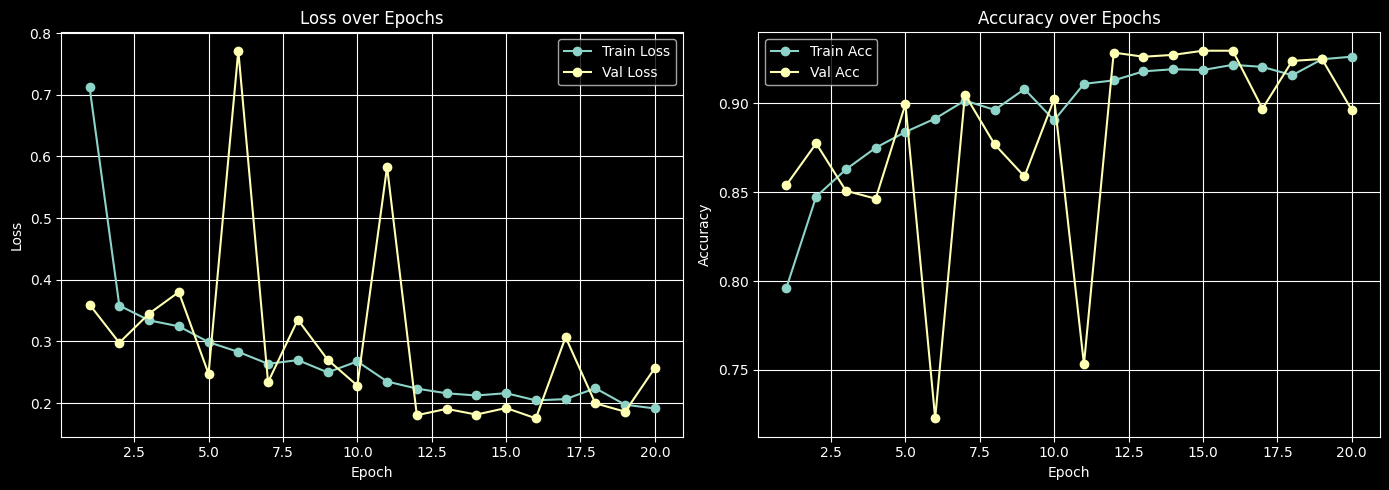

In [22]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(epochs, train_losses, label='Train Loss', marker='o')
ax1.plot(epochs, val_losses, label='Val Loss', marker='o')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(epochs, train_accs, label='Train Acc', marker='o')
ax2.plot(epochs, val_accs, label='Val Acc', marker='o')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# Check where the model is
print(f"Model device: {next(model.parameters()).device}")

# Check where a batch ends up
images, labels = next(iter(train_loader))
print(f"Images device before .to(device): {images.device}")
images = images.to(device)
print(f"Images device after .to(device):  {images.device}")

# Check CUDA memory
print(f"GPU memory allocated: {torch.cuda.memory_allocated(device) / 1024**2:.1f} MB")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {device}")

Model device: cuda:0
Images device before .to(device): cpu
Images device after .to(device):  cuda:0
GPU memory allocated: 452.0 MB
CUDA available: True
Device: cuda
